# Piotr Korcz PDD1

## Importy

In [1]:
import os
import random
import time

import pandas as pd
import matplotlib.pyplot as plt

from pyspark import StorageLevel
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    DoubleType,
    LongType,
    StringType,
)

## Spark na klastrze i ścieżki HDFS

In [2]:
spark = (
    SparkSession.builder
    .master("spark://master:7077")
    .appName("PDD14_MovieMatchLSH")
    .config("spark.executor.memory", "2g")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
sc = spark.sparkContext

RATINGS_PATH = "hdfs://master:9000/movielens/ml-32m/ratings.csv"
MOVIES_PATH = "hdfs://master:9000/movielens/ml-32m/movies.csv"
OUTPUT_PATH = "hdfs://master:9000/movielens/pdd14_out"

NUM_PARTITIONS = 200
NUM_BANDS = 20
ROWS_PER_BAND = 5
SIGNATURE_LENGTH = NUM_BANDS * ROWS_PER_BAND
THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7]
PRIME = 4294967311
SEED = 10

print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/15 21:21:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.1.1
Master: spark://master:7077


## Wczytanie danych

In [3]:
ratings_schema = StructType([
    StructField("userId", IntegerType(), True),
    StructField("movieId", IntegerType(), True),
    StructField("rating", DoubleType(), True),
    StructField("timestamp", LongType(), True),
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), True),
    StructField("title", StringType(), True),
    StructField("genres", StringType(), True),
])

ratings_df = (
    spark.read
    .option("header", True)
    .option("quote", '"')
    .option("escape", '"')
    .schema(ratings_schema)
    .csv(RATINGS_PATH)
    .repartition(NUM_PARTITIONS, "userId")
    .persist(StorageLevel.MEMORY_AND_DISK)
)

movies_df = (
    spark.read
    .option("header", True)
    .option("quote", '"')
    .option("escape", '"')
    .schema(movies_schema)
    .csv(MOVIES_PATH)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

ratings_df.createOrReplaceTempView("ratings")
movies_df.createOrReplaceTempView("movies")

print("ratings rows:", ratings_df.count())
print("movies rows:", movies_df.count())

ratings rows: 32000204


movies rows: 87585


## Funkcje pomocnicze do pokazywania i zapisywania wyników

In [4]:
def show_and_save(df, name, n=20):
    path = f"{OUTPUT_PATH}/{name}"
    (
        df.coalesce(1)
        .write
        .mode("overwrite")
        .option("header", True)
        .csv(path)
    )
    print(name)
    df.show(n, truncate=False)
    return df

## Widoki pomocnicze

In [5]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW ratings_enriched AS
SELECT
    r.userId,
    r.movieId,
    r.rating,
    r.timestamp,
    m.title,
    m.genres,
    year(from_unixtime(r.timestamp)) AS rating_year
FROM ratings r
JOIN movies m
ON r.movieId = m.movieId
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW movie_genres AS
SELECT
    movieId,
    title,
    explode(split(genres, '\\\\|')) AS genre
FROM movies
WHERE genres <> '(no genres listed)'
""")

genres_count_df = spark.sql("""
SELECT COUNT(DISTINCT genre) AS distinct_genres_count
FROM movie_genres
""")

show_and_save(genres_count_df, "00_genres_count")

00_genres_count


+---------------------+
|distinct_genres_count|
+---------------------+
|19                   |
+---------------------+



DataFrame[distinct_genres_count: bigint]

## 1. Liczba unikalnych użytkowników, filmów i wszystkich ocen

In [6]:
dataset_summary_df = spark.sql("""
SELECT
    COUNT(DISTINCT userId) AS unique_users,
    COUNT(DISTINCT movieId) AS unique_rated_movies,
    (SELECT COUNT(*) FROM movies) AS total_movies_in_catalog,
    COUNT(*) AS total_ratings
FROM ratings
""")

show_and_save(dataset_summary_df, "01_dataset_summary")

01_dataset_summary


+------------+-------------------+-----------------------+-------------+
|unique_users|unique_rated_movies|total_movies_in_catalog|total_ratings|
+------------+-------------------+-----------------------+-------------+
|200948      |84432              |87585                  |32000204     |
+------------+-------------------+-----------------------+-------------+



DataFrame[unique_users: bigint, unique_rated_movies: bigint, total_movies_in_catalog: bigint, total_ratings: bigint]

## 2. Średnie oceny filmów i użytkowników oraz histogramy

02_movie_avg_histogram_bins


+---------+-----+
|bin_start|count|
+---------+-----+
|0.5      |1324 |
|0.75     |189  |
|1.0      |1479 |
|1.25     |581  |
|1.5      |2137 |
|1.75     |1642 |
|2.0      |4882 |
|2.25     |3948 |
|2.5      |9185 |
|2.75     |8222 |
|3.0      |15359|
|3.25     |10694|
|3.5      |12685|
|3.75     |4795 |
|4.0      |4163 |
|4.25     |620  |
|4.5      |1008 |
|4.75     |74   |
|5.0      |1445 |
+---------+-----+



03_user_avg_histogram_bins


+---------+-----+
|bin_start|count|
+---------+-----+
|0.5      |25   |
|0.75     |23   |
|1.0      |72   |
|1.25     |117  |
|1.5      |217  |
|1.75     |353  |
|2.0      |708  |
|2.25     |1523 |
|2.5      |3365 |
|2.75     |7499 |
|3.0      |17004|
|3.25     |30667|
|3.5      |42963|
|3.75     |41526|
|4.0      |30883|
|4.25     |15649|
|4.5      |6160 |
|4.75     |1835 |
|5.0      |359  |
+---------+-----+



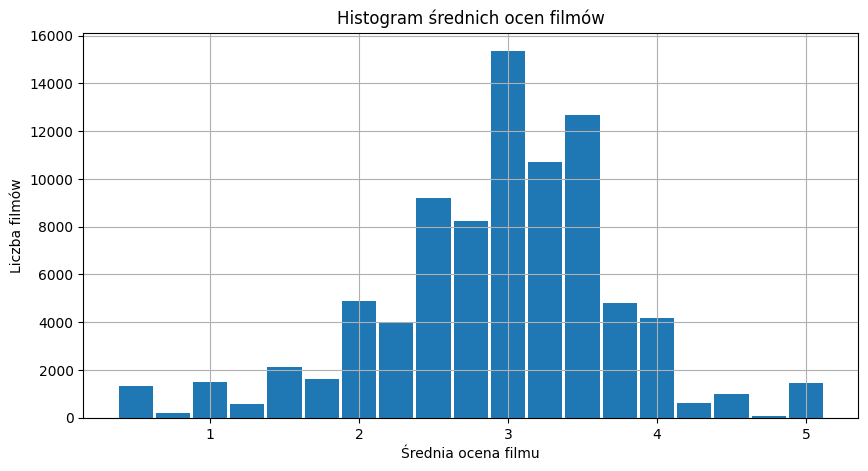

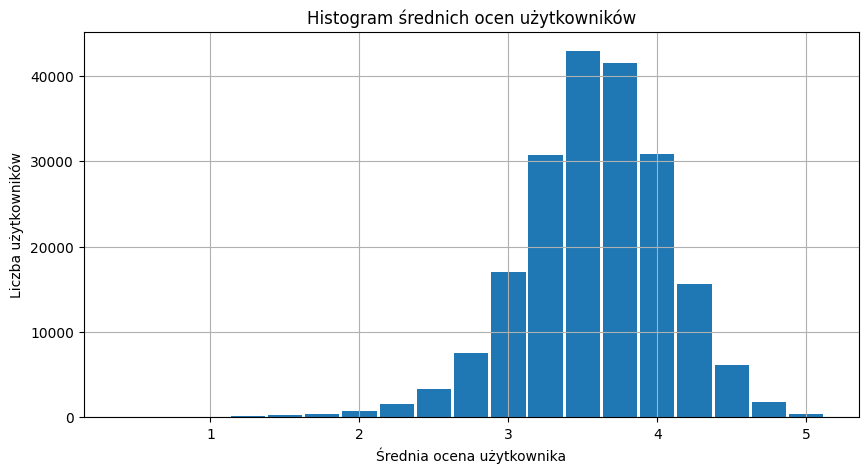

In [7]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW movie_avg_ratings AS
SELECT
    r.movieId,
    m.title,
    AVG(r.rating) AS avg_movie_rating,
    COUNT(*) AS movie_rating_count
FROM ratings r
JOIN movies m
ON r.movieId = m.movieId
GROUP BY r.movieId, m.title
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW user_avg_ratings AS
SELECT
    userId,
    AVG(rating) AS avg_user_rating,
    COUNT(*) AS user_rating_count
FROM ratings
GROUP BY userId
""")

movie_avg_hist_df = spark.sql("""
SELECT
    CAST(FLOOR(avg_movie_rating / 0.25) * 0.25 AS DOUBLE) AS bin_start,
    COUNT(*) AS count
FROM movie_avg_ratings
GROUP BY CAST(FLOOR(avg_movie_rating / 0.25) * 0.25 AS DOUBLE)
ORDER BY bin_start
""")

user_avg_hist_df = spark.sql("""
SELECT
    CAST(FLOOR(avg_user_rating / 0.25) * 0.25 AS DOUBLE) AS bin_start,
    COUNT(*) AS count
FROM user_avg_ratings
GROUP BY CAST(FLOOR(avg_user_rating / 0.25) * 0.25 AS DOUBLE)
ORDER BY bin_start
""")

show_and_save(movie_avg_hist_df, "02_movie_avg_histogram_bins", n=100)
show_and_save(user_avg_hist_df, "03_user_avg_histogram_bins", n=100)

movie_hist_pd = movie_avg_hist_df.toPandas()
user_hist_pd = user_avg_hist_df.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(movie_hist_pd["bin_start"], movie_hist_pd["count"], width=0.23)
plt.title("Histogram średnich ocen filmów")
plt.xlabel("Średnia ocena filmu")
plt.ylabel("Liczba filmów")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(user_hist_pd["bin_start"], user_hist_pd["count"], width=0.23)
plt.title("Histogram średnich ocen użytkowników")
plt.xlabel("Średnia ocena użytkownika")
plt.ylabel("Liczba użytkowników")
plt.grid(True)
plt.show()

## 3. Średnia ocen filmów i średnia ocen użytkowników

In [8]:
average_summary_df = spark.sql("""
SELECT
    ROUND((SELECT AVG(avg_movie_rating) FROM movie_avg_ratings), 6) AS avg_of_movie_averages,
    ROUND((SELECT AVG(avg_user_rating) FROM user_avg_ratings), 6) AS avg_of_user_averages,
    ROUND((SELECT AVG(rating) FROM ratings), 6) AS global_avg_rating
""")

show_and_save(average_summary_df, "04_average_summary")

04_average_summary


+---------------------+--------------------+-----------------+
|avg_of_movie_averages|avg_of_user_averages|global_avg_rating|
+---------------------+--------------------+-----------------+
|3.005082             |3.704368            |3.540396         |
+---------------------+--------------------+-----------------+



DataFrame[avg_of_movie_averages: double, avg_of_user_averages: double, global_avg_rating: double]

## 4. Liczba ocen w podziale na lata i rok największej aktywności

05_ratings_by_year


+-----------+-------------+
|rating_year|ratings_count|
+-----------+-------------+
|1995       |4            |
|1996       |1571368      |
|1997       |685388       |
|1998       |301691       |
|1999       |1174629      |
|2000       |1912322      |
|2001       |1160098      |
|2002       |849762       |
|2003       |1011000      |
|2004       |1139068      |
|2005       |1752573      |
|2006       |1141704      |
|2007       |1023813      |
|2008       |1117071      |
|2009       |890696       |
|2010       |860073       |
|2011       |729301       |
|2012       |695493       |
|2013       |563301       |
|2014       |518537       |
|2015       |1743866      |
|2016       |1918739      |
|2017       |1827953      |
|2018       |1391057      |
|2019       |1385467      |
|2020       |1688159      |
|2021       |1239912      |
|2022       |913105       |
|2023       |794054       |
+-----------+-------------+



06_most_active_year


+-----------+-------------+
|rating_year|ratings_count|
+-----------+-------------+
|2016       |1918739      |
+-----------+-------------+



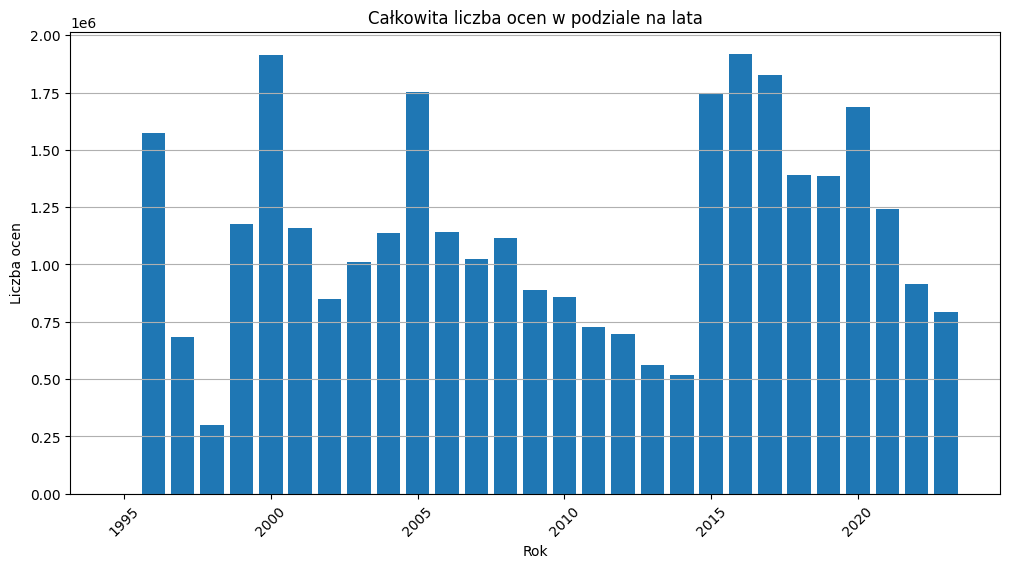

In [9]:
ratings_by_year_df = spark.sql("""
SELECT
    rating_year,
    COUNT(*) AS ratings_count
FROM ratings_enriched
WHERE rating_year IS NOT NULL
GROUP BY rating_year
ORDER BY rating_year
""")

show_and_save(ratings_by_year_df, "05_ratings_by_year", n=100)

most_active_year_df = spark.sql("""
SELECT
    rating_year,
    COUNT(*) AS ratings_count
FROM ratings_enriched
WHERE rating_year IS NOT NULL
GROUP BY rating_year
ORDER BY ratings_count DESC, rating_year ASC
LIMIT 1
""")

show_and_save(most_active_year_df, "06_most_active_year")

ratings_by_year_pd = ratings_by_year_df.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(ratings_by_year_pd["rating_year"], ratings_by_year_pd["ratings_count"])
plt.title("Całkowita liczba ocen w podziale na lata")
plt.xlabel("Rok")
plt.ylabel("Liczba ocen")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## 5. Średnia ocena gatunków i 5 najlepszych gatunków

In [10]:
genre_avg_ratings_df = spark.sql("""
SELECT
    mg.genre,
    AVG(r.rating) AS avg_genre_rating,
    COUNT(*) AS ratings_count,
    COUNT(DISTINCT r.movieId) AS movies_count
FROM ratings r
JOIN movie_genres mg
ON r.movieId = mg.movieId
WHERE mg.genre <> '(no genres listed)'
GROUP BY mg.genre
ORDER BY avg_genre_rating DESC, ratings_count DESC, genre ASC
""")

show_and_save(genre_avg_ratings_df, "07_genre_avg_ratings", n=100)

top5_genres_df = spark.sql("""
SELECT
    mg.genre,
    ROUND(AVG(r.rating), 4) AS avg_genre_rating,
    COUNT(*) AS ratings_count,
    COUNT(DISTINCT r.movieId) AS movies_count
FROM ratings r
JOIN movie_genres mg
ON r.movieId = mg.movieId
WHERE mg.genre <> '(no genres listed)'
GROUP BY mg.genre
ORDER BY avg_genre_rating DESC, ratings_count DESC, genre ASC
LIMIT 5
""")

show_and_save(top5_genres_df, "08_top5_genres_by_avg_rating")

07_genre_avg_ratings


+-----------+------------------+-------------+------------+
|genre      |avg_genre_rating  |ratings_count|movies_count|
+-----------+------------------+-------------+------------+
|Film-Noir  |3.915774014636868 |304710       |350         |
|War        |3.7916994435766664|1594110      |2225        |
|Crime      |3.6917711184948736|5373051      |6704        |
|Documentary|3.6911815290871948|427353       |9103        |
|Drama      |3.6824540581800784|13973271     |33152       |
|Mystery    |3.673102967818112 |2615322      |3894        |
|Animation  |3.6153322869262636|2214562      |4586        |
|Western    |3.6001753109842554|596654       |1489        |
|IMAX       |3.593312447839248 |1494179      |195         |
|Musical    |3.554276956937205 |1159516      |1033        |
|Romance    |3.5450028644529983|5524615      |10048       |
|Thriller   |3.5317020152396505|8679464      |11555       |
|Adventure  |3.5234385724723545|7590522      |5156        |
|Fantasy    |3.512174705402107 |3702759 

08_top5_genres_by_avg_rating


+-----------+----------------+-------------+------------+
|genre      |avg_genre_rating|ratings_count|movies_count|
+-----------+----------------+-------------+------------+
|Film-Noir  |3.9158          |304710       |350         |
|War        |3.7917          |1594110      |2225        |
|Crime      |3.6918          |5373051      |6704        |
|Documentary|3.6912          |427353       |9103        |
|Drama      |3.6825          |13973271     |33152       |
+-----------+----------------+-------------+------------+



DataFrame[genre: string, avg_genre_rating: double, ratings_count: bigint, movies_count: bigint]

## 6. Aktywni użytkownicy i ich 3 najczęściej oceniane gatunki

In [11]:
active_users_df = spark.sql("""
SELECT
    userId,
    COUNT(*) AS ratings_count
FROM ratings
GROUP BY userId
HAVING COUNT(*) > 1000
ORDER BY ratings_count DESC, userId ASC
""")

active_users_df.createOrReplaceTempView("active_users")

show_and_save(active_users_df, "09_active_users_over_1000", n=50)

active_user_ids_df = spark.sql("""
SELECT userId
FROM active_users
""")

active_user_ids_df.createOrReplaceTempView("active_user_ids")

active_user_top3_genres_df = spark.sql("""
WITH active_user_genre_counts AS (
    SELECT
        r.userId,
        mg.genre,
        COUNT(*) AS genre_rating_count
    FROM ratings r
    JOIN active_user_ids au
    ON r.userId = au.userId
    JOIN movie_genres mg
    ON r.movieId = mg.movieId
    WHERE mg.genre <> '(no genres listed)'
    GROUP BY r.userId, mg.genre
),
ranked AS (
    SELECT
        userId,
        genre,
        genre_rating_count,
        ROW_NUMBER() OVER (
            PARTITION BY userId
            ORDER BY genre_rating_count DESC, genre ASC
        ) AS genre_rank
    FROM active_user_genre_counts
)
SELECT
    userId,
    genre_rank,
    genre,
    genre_rating_count
FROM ranked
WHERE genre_rank <= 3
ORDER BY userId ASC, genre_rank ASC
""")

active_user_top3_genres_df.createOrReplaceTempView("active_user_top3_genres")

show_and_save(active_user_top3_genres_df, "10_active_users_top3_genres")

active_user_report_control_df = spark.sql("""
SELECT
    (SELECT COUNT(*) FROM active_users) AS active_users_count,
    (SELECT COUNT(DISTINCT userId) FROM active_user_top3_genres) AS users_with_top3_report,
    (SELECT COUNT(*) FROM active_user_top3_genres) AS rows_in_top3_report
""")

show_and_save(active_user_report_control_df, "11_active_user_report_control")

09_active_users_over_1000


+------+-------------+
|userId|ratings_count|
+------+-------------+
|175325|33332        |
|17035 |9577         |
|55653 |9178         |
|123465|9044         |
|171795|9016         |
|10202 |7748         |
|198515|7594         |
|49305 |7488         |
|22744 |7372         |
|7858  |7322         |
|14674 |6407         |
|53192 |6265         |
|133878|6074         |
|57304 |6061         |
|129705|5812         |
|139018|5806         |
|43703 |5784         |
|68797 |5693         |
|103925|5655         |
|119247|5654         |
|8588  |5649         |
|134403|5633         |
|37677 |5542         |
|87007 |5525         |
|162621|5515         |
|8359  |5419         |
|9085  |5400         |
|91195 |5319         |
|15875 |5244         |
|142343|5244         |
|83000 |5160         |
|78394 |5141         |
|200323|5083         |
|139755|5073         |
|147603|5061         |
|173979|5004         |
|8307  |4861         |
|94272 |4843         |
|181059|4827         |
|54798 |4806         |
|52617 |478

10_active_users_top3_genres


+------+----------+--------+------------------+
|userId|genre_rank|genre   |genre_rating_count|
+------+----------+--------+------------------+
|28    |1         |Drama   |1373              |
|28    |2         |Comedy  |1118              |
|28    |3         |Action  |722               |
|188   |1         |Drama   |1089              |
|188   |2         |Comedy  |1013              |
|188   |3         |Romance |530               |
|265   |1         |Comedy  |941               |
|265   |2         |Thriller|821               |
|265   |3         |Horror  |769               |
|354   |1         |Drama   |752               |
|354   |2         |Comedy  |369               |
|354   |3         |Thriller|327               |
|360   |1         |Comedy  |508               |
|360   |2         |Drama   |446               |
|360   |3         |Action  |340               |
|447   |1         |Drama   |529               |
|447   |2         |Action  |392               |
|447   |3         |Thriller|372         

11_active_user_report_control


+------------------+----------------------+-------------------+
|active_users_count|users_with_top3_report|rows_in_top3_report|
+------------------+----------------------+-------------------+
|3614              |3614                  |10842              |
+------------------+----------------------+-------------------+



DataFrame[active_users_count: bigint, users_with_top3_report: bigint, rows_in_top3_report: bigint]

## 7. Filtrowanie danych do LSH

In [12]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW valid_movies AS
SELECT
    movieId
FROM ratings
GROUP BY movieId
HAVING COUNT(*) >= 50
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW ratings_after_movie_filter AS
SELECT
    r.userId,
    r.movieId,
    r.rating
FROM ratings r
JOIN valid_movies vm
ON r.movieId = vm.movieId
""")

spark.sql("""
CREATE OR REPLACE TEMP VIEW valid_users AS
SELECT
    userId
FROM ratings_after_movie_filter
GROUP BY userId
HAVING COUNT(*) >= 20
""")

filtered_ratings_df = spark.sql("""
SELECT
    rmf.userId,
    rmf.movieId,
    rmf.rating
FROM ratings_after_movie_filter rmf
JOIN valid_users vu
ON rmf.userId = vu.userId
""").repartition(NUM_PARTITIONS, "userId").persist(StorageLevel.MEMORY_AND_DISK)

filtered_ratings_df.count()
filtered_ratings_df.createOrReplaceTempView("filtered_ratings")

filter_counts_df = spark.sql("""
SELECT
    (SELECT COUNT(*) FROM valid_movies) AS movies_after_min_50_ratings,
    (SELECT COUNT(*) FROM valid_users) AS users_after_min_20_ratings,
    (SELECT COUNT(*) FROM filtered_ratings) AS ratings_after_filtering
""")

show_and_save(filter_counts_df, "12_lsh_filter_counts")

12_lsh_filter_counts


+---------------------------+--------------------------+-----------------------+
|movies_after_min_50_ratings|users_after_min_20_ratings|ratings_after_filtering|
+---------------------------+--------------------------+-----------------------+
|16034                      |200559                    |31491808               |
+---------------------------+--------------------------+-----------------------+



DataFrame[movies_after_min_50_ratings: bigint, users_after_min_20_ratings: bigint, ratings_after_filtering: bigint]

## 8. Zbiory filmów lubianych i nielubianych

In [13]:
liked_df = spark.sql("""
SELECT
    userId,
    COLLECT_SET(movieId) AS movies,
    SIZE(COLLECT_SET(movieId)) AS set_size
FROM filtered_ratings
WHERE rating >= 4.0
GROUP BY userId
HAVING SIZE(COLLECT_SET(movieId)) > 0
""").persist(StorageLevel.MEMORY_AND_DISK)

disliked_df = spark.sql("""
SELECT
    userId,
    COLLECT_SET(movieId) AS movies,
    SIZE(COLLECT_SET(movieId)) AS set_size
FROM filtered_ratings
WHERE rating <= 2.0
GROUP BY userId
HAVING SIZE(COLLECT_SET(movieId)) > 0
""").persist(StorageLevel.MEMORY_AND_DISK)

liked_df.count()
disliked_df.count()

liked_df.createOrReplaceTempView("user_liked")
disliked_df.createOrReplaceTempView("user_disliked")

set_sizes_df = spark.sql("""
SELECT
    set_type,
    COUNT(*) AS users_count,
    AVG(set_size) AS avg_set_size,
    percentile_approx(set_size, 0.5) AS median_set_size,
    MIN(set_size) AS min_set_size,
    MAX(set_size) AS max_set_size
FROM (
    SELECT
        'liked_rating_ge_4' AS set_type,
        set_size
    FROM user_liked
    UNION ALL
    SELECT
        'disliked_rating_le_2' AS set_type,
        set_size
    FROM user_disliked
)
GROUP BY set_type
ORDER BY set_type
""")

show_and_save(set_sizes_df, "13_lsh_input_set_sizes")

pair_space_df = spark.sql("""
SELECT
    set_type,
    users_count,
    users_count * (users_count - 1) / 2 AS all_possible_pairs
FROM (
    SELECT
        'liked_rating_ge_4' AS set_type,
        COUNT(*) AS users_count
    FROM user_liked
    UNION ALL
    SELECT
        'disliked_rating_le_2' AS set_type,
        COUNT(*) AS users_count
    FROM user_disliked
)
""")

show_and_save(pair_space_df, "14_lsh_pair_space")

13_lsh_input_set_sizes


+--------------------+-----------+----------------+---------------+------------+------------+
|set_type            |users_count|avg_set_size    |median_set_size|min_set_size|max_set_size|
+--------------------+-----------+----------------+---------------+------------+------------+
|disliked_rating_le_2|172115     |22.7660575777823|7              |1           |4759        |
|liked_rating_ge_4   |200338     |78.8414479529595|42             |1           |3650        |
+--------------------+-----------+----------------+---------------+------------+------------+



14_lsh_pair_space


+--------------------+-----------+------------------+
|set_type            |users_count|all_possible_pairs|
+--------------------+-----------+------------------+
|liked_rating_ge_4   |200338     |2.0067556953E10   |
|disliked_rating_le_2|172115     |1.4811700555E10   |
+--------------------+-----------+------------------+



DataFrame[set_type: string, users_count: bigint, all_possible_pairs: double]

## 9. MinHash i bandy LSH

In [14]:
random.seed(SEED)

hash_params = [
    (
        random.randint(1, PRIME - 1),
        random.randint(0, PRIME - 1)
    )
    for _ in range(SIGNATURE_LENGTH)
]

hash_params_bc = sc.broadcast(hash_params)


def compute_minhash_signature(movie_set):
    if movie_set is None or len(movie_set) == 0:
        return tuple()

    params = hash_params_bc.value
    signature = []

    for a, b in params:
        min_hash = PRIME
        for movie_id in movie_set:
            h = (a * movie_id + b) % PRIME
            if h < min_hash:
                min_hash = h
        signature.append(int(min_hash))

    return tuple(signature)


def create_user_movies_rdd(df):
    return (
        df.rdd
        .map(lambda r: (
            int(r["userId"]),
            frozenset(int(x) for x in r["movies"])
        ))
        .mapValues(lambda s: (s, len(s)))
        .partitionBy(NUM_PARTITIONS)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )


user_liked_movies = create_user_movies_rdd(liked_df)
user_disliked_movies = create_user_movies_rdd(disliked_df)


def create_signatures(user_movies, label):
    start = time.time()

    signatures = (
        user_movies
        .map(lambda x: (
            x[0],
            x[1][0],
            x[1][1],
            compute_minhash_signature(x[1][0])
        ))
        .filter(lambda x: len(x[3]) == SIGNATURE_LENGTH)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    print(label, "signatures:", signatures.count())
    print(label, "signature time [min]:", round((time.time() - start) / 60, 2))

    return signatures


def signature_to_bands(record):
    user_id, movie_set, set_size, signature = record

    for band_id in range(NUM_BANDS):
        start = band_id * ROWS_PER_BAND
        end = start + ROWS_PER_BAND
        band_values = signature[start:end]
        yield ((band_id, band_values), user_id)


def create_bands(signatures, label):
    bands = (
        signatures
        .flatMap(signature_to_bands)
        .partitionBy(NUM_PARTITIONS)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    print(label, "band rows:", bands.count())

    return bands


liked_signatures = create_signatures(user_liked_movies, "liked")
disliked_signatures = create_signatures(user_disliked_movies, "disliked")

liked_bands = create_bands(liked_signatures, "liked")
disliked_bands = create_bands(disliked_signatures, "disliked")

liked signatures: 200338
liked signature time [min]: 8.49


disliked signatures: 172115
disliked signature time [min]: 3.92


liked band rows: 4006760


disliked band rows: 3442300


## 10. Kandydaci LSH

In [15]:
def create_lsh_candidates(bands, label):
    start = time.time()

    bucket_users = (
        bands
        .groupByKey(numPartitions=NUM_PARTITIONS)
        .mapValues(lambda users: sorted(set(users)))
        .filter(lambda x: len(x[1]) >= 2)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    bucket_stats = (
        bucket_users
        .map(lambda x: len(x[1]))
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    bucket_count = bucket_stats.count()

    if bucket_count == 0:
        stats_row = [(label, 0, 0, 0.0, 0)]
    else:
        stats = bucket_stats.stats()
        stats_row = [(
            label,
            int(stats.count()),
            int(stats.min()),
            float(stats.mean()),
            int(stats.max())
        )]

    bucket_stats_df = spark.createDataFrame(
        stats_row,
        ["set_type", "nontrivial_buckets", "min_bucket_size", "avg_bucket_size", "max_bucket_size"]
    )

    show_and_save(bucket_stats_df, f"15_{label}_bucket_stats")

    def make_candidate_pairs(bucket_record):
        bucket_key, users = bucket_record
        for i in range(len(users)):
            for j in range(i + 1, len(users)):
                yield (users[i], users[j])

    candidates = (
        bucket_users
        .flatMap(make_candidate_pairs)
        .distinct(NUM_PARTITIONS)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    candidate_count = candidates.count()

    user_count = (
        bands
        .map(lambda x: x[1])
        .distinct(NUM_PARTITIONS)
        .count()
    )

    all_possible_pairs = user_count * (user_count - 1) / 2

    if all_possible_pairs > 0:
        reduction_pct = 100.0 * (1.0 - candidate_count / all_possible_pairs)
    else:
        reduction_pct = 0.0

    reduction_df = spark.createDataFrame(
        [(
            label,
            int(user_count),
            int(all_possible_pairs),
            int(candidate_count),
            float(reduction_pct)
        )],
        ["set_type", "users_count", "all_possible_pairs", "lsh_candidates", "reduction_pct"]
    )

    show_and_save(reduction_df, f"16_{label}_lsh_reduction")

    print(label, "candidate time [min]:", round((time.time() - start) / 60, 2))

    bucket_stats.unpersist(blocking=False)
    bucket_users.unpersist(blocking=False)

    return candidates


liked_candidates = create_lsh_candidates(liked_bands, "liked")
disliked_candidates = create_lsh_candidates(disliked_bands, "disliked")

liked_bands.unpersist(blocking=False)
disliked_bands.unpersist(blocking=False)
liked_signatures.unpersist(blocking=False)
disliked_signatures.unpersist(blocking=False)
hash_params_bc.destroy()

15_liked_bucket_stats


+--------+------------------+---------------+------------------+---------------+
|set_type|nontrivial_buckets|min_bucket_size|avg_bucket_size   |max_bucket_size|
+--------+------------------+---------------+------------------+---------------+
|liked   |169959            |2              |3.4332574326749388|398            |
+--------+------------------+---------------+------------------+---------------+



16_liked_lsh_reduction


+--------+-----------+------------------+--------------+-----------------+
|set_type|users_count|all_possible_pairs|lsh_candidates|reduction_pct    |
+--------+-----------+------------------+--------------+-----------------+
|liked   |200338     |20067556953       |3011023       |99.98499556768643|
+--------+-----------+------------------+--------------+-----------------+

liked candidate time [min]: 6.76


15_disliked_bucket_stats


+--------+------------------+---------------+-----------------+---------------+
|set_type|nontrivial_buckets|min_bucket_size|avg_bucket_size  |max_bucket_size|
+--------+------------------+---------------+-----------------+---------------+
|disliked|91918             |2              |6.058356361104467|469            |
+--------+------------------+---------------+-----------------+---------------+



16_disliked_lsh_reduction


+--------+-----------+------------------+--------------+-----------------+
|set_type|users_count|all_possible_pairs|lsh_candidates|reduction_pct    |
+--------+-----------+------------------+--------------+-----------------+
|disliked|172115     |14811700555       |1482092       |99.98999377556616|
+--------+-----------+------------------+--------------+-----------------+

disliked candidate time [min]: 7.15


## 11. Dokładny Jaccard dla kandydatów

In [16]:
def create_jaccard_scores(candidates, user_movies, label):
    start = time.time()

    user_sets = (
        user_movies
        .partitionBy(NUM_PARTITIONS)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    joined_first = (
        candidates
        .map(lambda pair: (pair[0], pair))
        .partitionBy(NUM_PARTITIONS)
        .join(user_sets, numPartitions=NUM_PARTITIONS)
    )

    joined_first_by_second = (
        joined_first
        .map(lambda x: (
            x[1][0][1],
            (x[1][0][0], x[1][0][1], x[1][1][0], x[1][1][1])
        ))
        .partitionBy(NUM_PARTITIONS)
    )

    joined_second = (
        joined_first_by_second
        .join(user_sets, numPartitions=NUM_PARTITIONS)
        .map(lambda x: (
            x[1][0][0],
            x[1][0][1],
            x[1][0][2],
            x[1][0][3],
            x[1][1][0],
            x[1][1][1]
        ))
    )

    def score_pair(record):
        user_id1, user_id2, set1, size1, set2, size2 = record

        if size1 <= size2:
            intersection_size = sum(1 for movie_id in set1 if movie_id in set2)
        else:
            intersection_size = sum(1 for movie_id in set2 if movie_id in set1)

        union_size = size1 + size2 - intersection_size

        if union_size == 0:
            jaccard_similarity = 0.0
        else:
            jaccard_similarity = intersection_size / union_size

        return (
            (user_id1, user_id2),
            (intersection_size, union_size, jaccard_similarity)
        )

    scores = (
        joined_second
        .map(score_pair)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    pairs_count = scores.count()

    top30 = (
        scores
        .takeOrdered(30, key=lambda x: (-x[1][2], x[0][0], x[0][1]))
    )

    top30_rows = [
        (
            int(pair[0]),
            int(pair[1]),
            int(values[0]),
            int(values[1]),
            float(values[2])
        )
        for pair, values in top30
    ]

    top30_df = spark.createDataFrame(
        top30_rows,
        ["u1", "u2", "intersection_size", "union_size", "jaccard"]
    )

    show_and_save(top30_df, f"17_{label}_top30_pairs_by_jaccard", n=30)

    print(label, "jaccard pairs:", pairs_count)
    print(label, "jaccard time [min]:", round((time.time() - start) / 60, 2))

    user_sets.unpersist(blocking=False)

    return scores


liked_scores = create_jaccard_scores(liked_candidates, user_liked_movies, "liked")
disliked_scores = create_jaccard_scores(disliked_candidates, user_disliked_movies, "disliked")

17_liked_top30_pairs_by_jaccard


+-----+------+-----------------+----------+-------+
|u1   |u2    |intersection_size|union_size|jaccard|
+-----+------+-----------------+----------+-------+
|4848 |37861 |1                |1         |1.0    |
|4848 |45591 |1                |1         |1.0    |
|4848 |168527|1                |1         |1.0    |
|7497 |181565|1                |1         |1.0    |
|7569 |23738 |1                |1         |1.0    |
|7569 |50222 |1                |1         |1.0    |
|7569 |53614 |1                |1         |1.0    |
|7569 |54582 |1                |1         |1.0    |
|7569 |61753 |1                |1         |1.0    |
|7569 |75674 |1                |1         |1.0    |
|7569 |109659|1                |1         |1.0    |
|7569 |121495|1                |1         |1.0    |
|7615 |180260|18               |18        |1.0    |
|11849|86861 |2                |2         |1.0    |
|14604|115002|1                |1         |1.0    |
|15246|42888 |1                |1         |1.0    |
|18572|18677

17_disliked_top30_pairs_by_jaccard


+---+------+-----------------+----------+-------+
|u1 |u2    |intersection_size|union_size|jaccard|
+---+------+-----------------+----------+-------+
|27 |30361 |1                |1         |1.0    |
|27 |61907 |1                |1         |1.0    |
|27 |62073 |1                |1         |1.0    |
|27 |72634 |1                |1         |1.0    |
|27 |73913 |1                |1         |1.0    |
|27 |83668 |1                |1         |1.0    |
|27 |95153 |1                |1         |1.0    |
|27 |98589 |1                |1         |1.0    |
|27 |98905 |1                |1         |1.0    |
|27 |101283|1                |1         |1.0    |
|27 |102398|1                |1         |1.0    |
|27 |107051|1                |1         |1.0    |
|27 |125843|1                |1         |1.0    |
|27 |128733|1                |1         |1.0    |
|27 |139478|1                |1         |1.0    |
|27 |144410|1                |1         |1.0    |
|27 |154534|1                |1         |1.0    |


## 12. Wpływ thresholda i przecięcie kandydatów liked/disliked

18_lsh_threshold_intersection_analysis


+---------+-----------------+--------------------+------------------+-----------+-------------------------+-------------------------+----------------------------+
|threshold|liked_pairs_count|disliked_pairs_count|intersection_count|union_count|intersection_pct_of_union|intersection_pct_of_liked|intersection_pct_of_disliked|
+---------+-----------------+--------------------+------------------+-----------+-------------------------+-------------------------+----------------------------+
|0.1      |2859384          |1478925             |10491             |4327818    |0.2424085301184107       |0.36689720583174557      |0.7093666007404027          |
|0.2      |1746705          |1444197             |10084             |3180818    |0.31702536894597555      |0.577315574181101        |0.6982426912671886          |
|0.3      |798440           |1318805             |7582              |2109663    |0.3593938937166742       |0.949601723360553        |0.5749144111525206          |
|0.4      |274379     

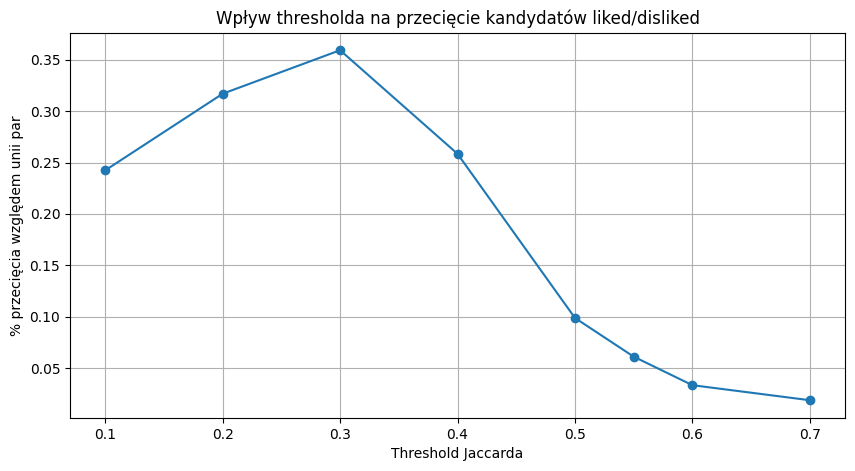

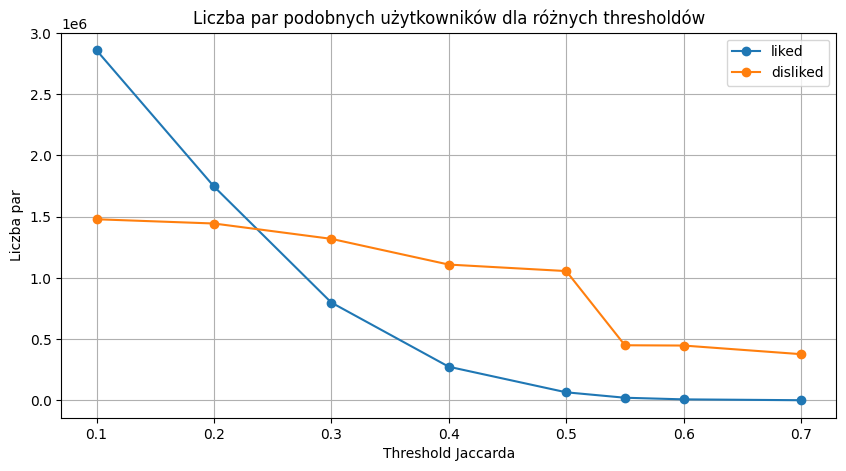

In [17]:
def count_accepted_by_threshold(scores):
    initial = {threshold: 0 for threshold in THRESHOLDS}

    def seq_op(acc, record):
        jaccard = record[1][2]
        for threshold in THRESHOLDS:
            if jaccard >= threshold:
                acc[threshold] += 1
        return acc

    def comb_op(acc1, acc2):
        return {
            threshold: acc1[threshold] + acc2[threshold]
            for threshold in THRESHOLDS
        }

    return scores.aggregate(initial, seq_op, comb_op)


liked_pair_scores = (
    liked_scores
    .map(lambda x: (x[0], x[1][2]))
    .partitionBy(NUM_PARTITIONS)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

disliked_pair_scores = (
    disliked_scores
    .map(lambda x: (x[0], x[1][2]))
    .partitionBy(NUM_PARTITIONS)
    .persist(StorageLevel.MEMORY_AND_DISK)
)

common_liked_disliked_scores = (
    liked_pair_scores
    .join(disliked_pair_scores, numPartitions=NUM_PARTITIONS)
    .persist(StorageLevel.MEMORY_AND_DISK)
)


def count_common_by_threshold(common_scores):
    initial = {threshold: 0 for threshold in THRESHOLDS}

    def seq_op(acc, record):
        liked_jaccard = record[1][0]
        disliked_jaccard = record[1][1]
        for threshold in THRESHOLDS:
            if liked_jaccard >= threshold and disliked_jaccard >= threshold:
                acc[threshold] += 1
        return acc

    def comb_op(acc1, acc2):
        return {
            threshold: acc1[threshold] + acc2[threshold]
            for threshold in THRESHOLDS
        }

    return common_scores.aggregate(initial, seq_op, comb_op)


liked_counts = count_accepted_by_threshold(liked_scores)
disliked_counts = count_accepted_by_threshold(disliked_scores)
common_counts = count_common_by_threshold(common_liked_disliked_scores)

threshold_rows = []

for threshold in THRESHOLDS:
    liked_accepted = liked_counts[threshold]
    disliked_accepted = disliked_counts[threshold]
    common_accepted = common_counts[threshold]
    union_size = liked_accepted + disliked_accepted - common_accepted

    if union_size > 0:
        intersection_pct_of_union = 100.0 * common_accepted / union_size
    else:
        intersection_pct_of_union = 0.0

    if liked_accepted > 0:
        intersection_pct_of_liked = 100.0 * common_accepted / liked_accepted
    else:
        intersection_pct_of_liked = 0.0

    if disliked_accepted > 0:
        intersection_pct_of_disliked = 100.0 * common_accepted / disliked_accepted
    else:
        intersection_pct_of_disliked = 0.0

    threshold_rows.append((
        float(threshold),
        int(liked_accepted),
        int(disliked_accepted),
        int(common_accepted),
        int(union_size),
        float(intersection_pct_of_union),
        float(intersection_pct_of_liked),
        float(intersection_pct_of_disliked)
    ))

threshold_analysis_df = spark.createDataFrame(
    threshold_rows,
    [
        "threshold",
        "liked_pairs_count",
        "disliked_pairs_count",
        "intersection_count",
        "union_count",
        "intersection_pct_of_union",
        "intersection_pct_of_liked",
        "intersection_pct_of_disliked"
    ]
)

show_and_save(threshold_analysis_df, "18_lsh_threshold_intersection_analysis")

threshold_pd = threshold_analysis_df.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(
    threshold_pd["threshold"],
    threshold_pd["intersection_pct_of_union"],
    marker="o"
)
plt.title("Wpływ thresholda na przecięcie kandydatów liked/disliked")
plt.xlabel("Threshold Jaccarda")
plt.ylabel("% przecięcia względem unii par")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    threshold_pd["threshold"],
    threshold_pd["liked_pairs_count"],
    marker="o",
    label="liked"
)
plt.plot(
    threshold_pd["threshold"],
    threshold_pd["disliked_pairs_count"],
    marker="o",
    label="disliked"
)
plt.title("Liczba par podobnych użytkowników dla różnych thresholdów")
plt.xlabel("Threshold Jaccarda")
plt.ylabel("Liczba par")
plt.legend()
plt.grid(True)
plt.show()

## Czyszczenie pamięci

In [18]:
liked_pair_scores.unpersist(blocking=False)
disliked_pair_scores.unpersist(blocking=False)
common_liked_disliked_scores.unpersist(blocking=False)
liked_scores.unpersist(blocking=False)
disliked_scores.unpersist(blocking=False)
liked_candidates.unpersist(blocking=False)
disliked_candidates.unpersist(blocking=False)
user_liked_movies.unpersist(blocking=False)
user_disliked_movies.unpersist(blocking=False)
liked_df.unpersist(blocking=False)
disliked_df.unpersist(blocking=False)
filtered_ratings_df.unpersist(blocking=False)
ratings_df.unpersist(blocking=False)
movies_df.unpersist(blocking=False)

spark.catalog.clearCache()

print("Wyniki zapisane w:", OUTPUT_PATH)

Wyniki zapisane w: hdfs://master:9000/movielens/pdd14_out
